MAE: 4.214763142474852
MSE: 29.09516986671551
R2: 0.8804332983749564


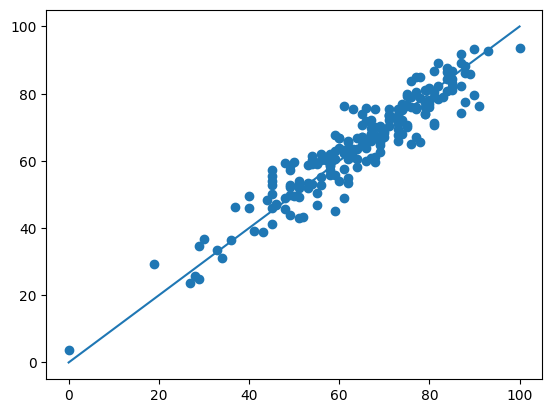

Interpretation: Strong model with good fit. Predictions are close to actual values.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/StudentsPerformance.csv')

X = df.drop("math score", axis=1)
y = df["math score"]

cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([("cat", OneHotEncoder(drop="first"), cat)], remainder="passthrough")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = Pipeline([("pre",pre),("model",LinearRegression())])
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

if r2>0.85:
    print("Interpretation: Strong model with good fit. Predictions are close to actual values.")
elif r2>0.7:
    print("Interpretation: Moderate model performance with some prediction errors.")
else:
    print("Interpretation: Weak model with high prediction error.")

Best Params: {'model__alpha': 1}
MAE: 4.214216440671403
MSE: 29.121240871114434
R2: 0.8803261594918252


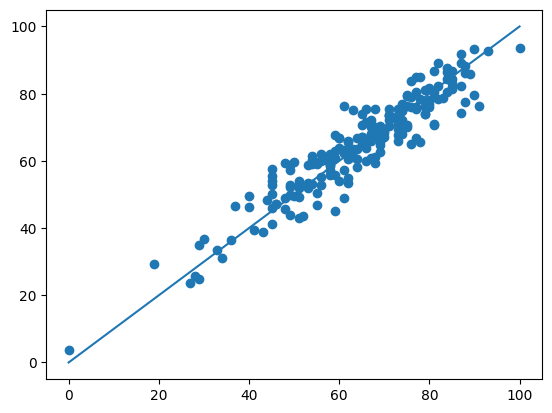

Interpretation: Hyperparameter tuning improved generalization and reduced overfitting.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/StudentsPerformance.csv')

X = df.drop("math score", axis=1)
y = df["math score"]

cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([("cat", OneHotEncoder(drop="first"), cat)], remainder="passthrough")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

pipe = Pipeline([("pre",pre),("model",Ridge())])

params = {"model__alpha":[0.01,0.1,1,10,100]}

grid = GridSearchCV(pipe,params,cv=5)
grid.fit(X_train,y_train)

model = grid.best_estimator_

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Best Params:",grid.best_params_)
print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

print("Interpretation: Hyperparameter tuning improved generalization and reduced overfitting.")

MAE: 4.14853142437036
MSE: 28.699072368950066
R2: 0.8820610624178097


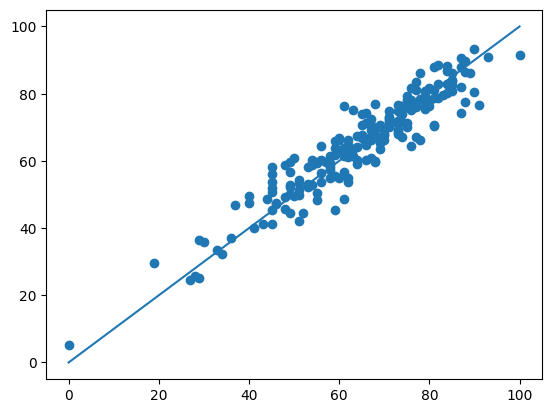

Interpretation: Lasso performs feature selection and simplifies the model.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/StudentsPerformance.csv')

X = df.drop("math score", axis=1)
y = df["math score"]

cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([("cat", OneHotEncoder(drop="first"), cat)], remainder="passthrough")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = Pipeline([("pre",pre),("model",Lasso(alpha=0.1))])
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

print("Interpretation: Lasso performs feature selection and simplifies the model.")

Best Params: {'model__alpha': 0.01}
MAE: 4.203990567189841
MSE: 28.977491902653398
R2: 0.8809168963770067


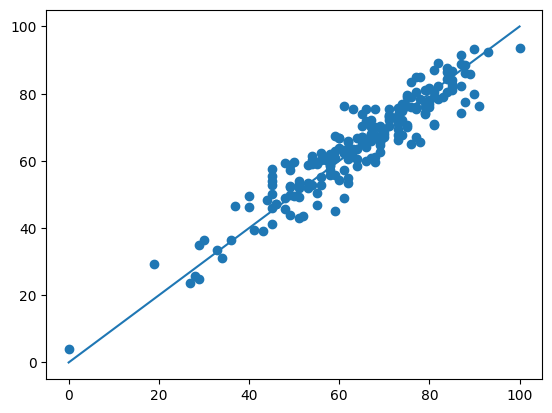

Interpretation: Tuned Lasso balances simplicity and performance with better feature selection.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/StudentsPerformance.csv')

X = df.drop("math score", axis=1)
y = df["math score"]

cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([("cat", OneHotEncoder(drop="first"), cat)], remainder="passthrough")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

pipe = Pipeline([("pre",pre),("model",Lasso())])

params = {"model__alpha":[0.01,0.1,1,10,100]}

grid = GridSearchCV(pipe,params,cv=5)
grid.fit(X_train,y_train)

model = grid.best_estimator_

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Best Params:",grid.best_params_)
print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

print("Interpretation: Tuned Lasso balances simplicity and performance with better feature selection.")

MAE: 4.214216440671403
MSE: 29.121240871114434
R2: 0.8803261594918252


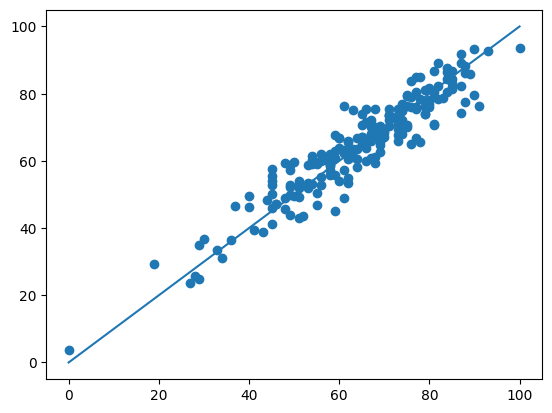

Interpretation: Ridge reduces overfitting and improves stability of coefficients.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/StudentsPerformance.csv')

X = df.drop("math score", axis=1)
y = df["math score"]

cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([("cat", OneHotEncoder(drop="first"), cat)], remainder="passthrough")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = Pipeline([("pre",pre),("model",Ridge(alpha=1.0))])
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

print("Interpretation: Ridge reduces overfitting and improves stability of coefficients.")

Best Params: {'model__alpha': 1}
MAE: 4.214216440671403
MSE: 29.121240871114434
R2: 0.8803261594918252


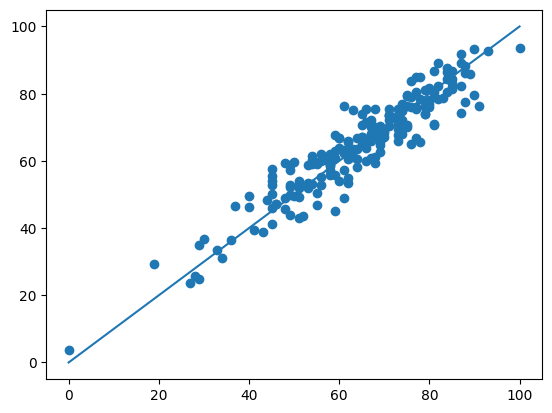

Interpretation: Tuned Ridge gives best generalization and handles multicollinearity effectively.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/StudentsPerformance.csv')

X = df.drop("math score", axis=1)
y = df["math score"]

cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([("cat", OneHotEncoder(drop="first"), cat)], remainder="passthrough")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

pipe = Pipeline([("pre",pre),("model",Ridge())])

params = {"model__alpha":[0.01,0.1,1,10,100]}

grid = GridSearchCV(pipe,params,cv=5)
grid.fit(X_train,y_train)

model = grid.best_estimator_

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Best Params:",grid.best_params_)
print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

print("Interpretation: Tuned Ridge gives best generalization and handles multicollinearity effectively.")